In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
df_steam = pd.read_csv('steam.csv')
df_steam.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [3]:
df_steam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [4]:
# Filtrando apenas jogos que tem 'Indie' na coluna de gêneros
df_indie = df_steam[df_steam['genres'].str.contains('Indie', na=False)].copy()

# Selecionando apenas as colunas úteis para a análise
colunas_uteis = ['name', 'release_date', 'developer', 'platforms', 'genres', 
                 'positive_ratings', 'negative_ratings', 'average_playtime', 'price']
df_limpo = df_indie[colunas_uteis].copy()

# Criando a métrica de sucesso: Taxa de Aprovação
df_limpo['total_ratings'] = df_limpo['positive_ratings'] + df_limpo['negative_ratings']

# Calculo da porcentagem 
df_limpo['taxa_aprovacao'] = (df_limpo['positive_ratings'] / df_limpo['total_ratings']) * 100

# Removendo os jogos que não tiveram nenhuma avaliação (para evitar divisão por zero)
df_limpo = df_limpo.dropna(subset=['taxa_aprovacao'])

# Mostrar o resultado
print(f"Total de jogos Indie analisados: {len(df_limpo)}")
df_limpo[['name', 'price', 'total_ratings', 'taxa_aprovacao']].head()

Total de jogos Indie analisados: 19421


,name,price,total_ratings,taxa_aprovacao
26,Rag Doll Kung Fu,5.99,57,70.175439
30,Darwinia,7.19,630,74.920635
31,Uplink,6.99,1754,91.334094
32,DEFCON,7.19,2401,85.672636
33,Multiwinia,7.19,443,83.069977


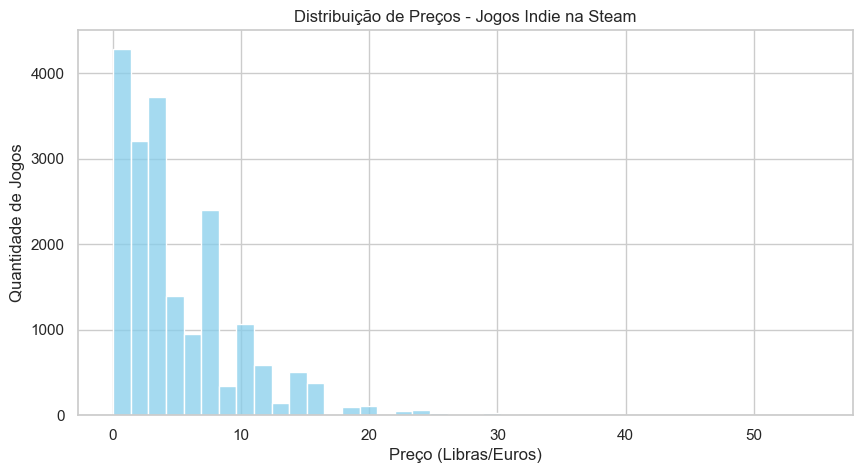

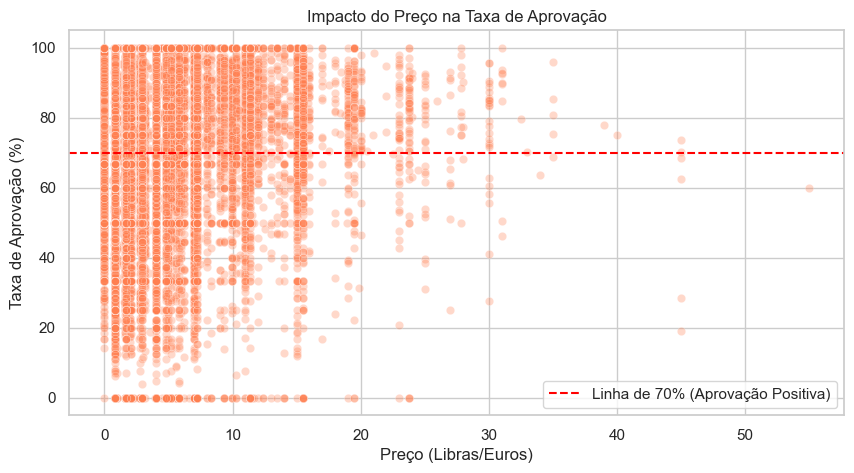

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual
sns.set_theme(style="whitegrid")

# Removendo os jogos com preços absurdos (outliers maiores que 60) para não distorcer o gráfico
df_graficos = df_limpo[df_limpo['price'] <= 60].copy()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_graficos, x='price', bins=40, color='skyblue')
plt.title('Distribuição de Preços - Jogos Indie na Steam')
plt.xlabel('Preço (Libras/Euros)')
plt.ylabel('Quantidade de Jogos')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_graficos, x='price', y='taxa_aprovacao', alpha=0.3, color='coral')
plt.title('Impacto do Preço na Taxa de Aprovação')
plt.xlabel('Preço (Libras/Euros)')
plt.ylabel('Taxa de Aprovação (%)')
plt.axhline(y=70, color='red', linestyle='--', label='Linha de 70% (Aprovação Positiva)')
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

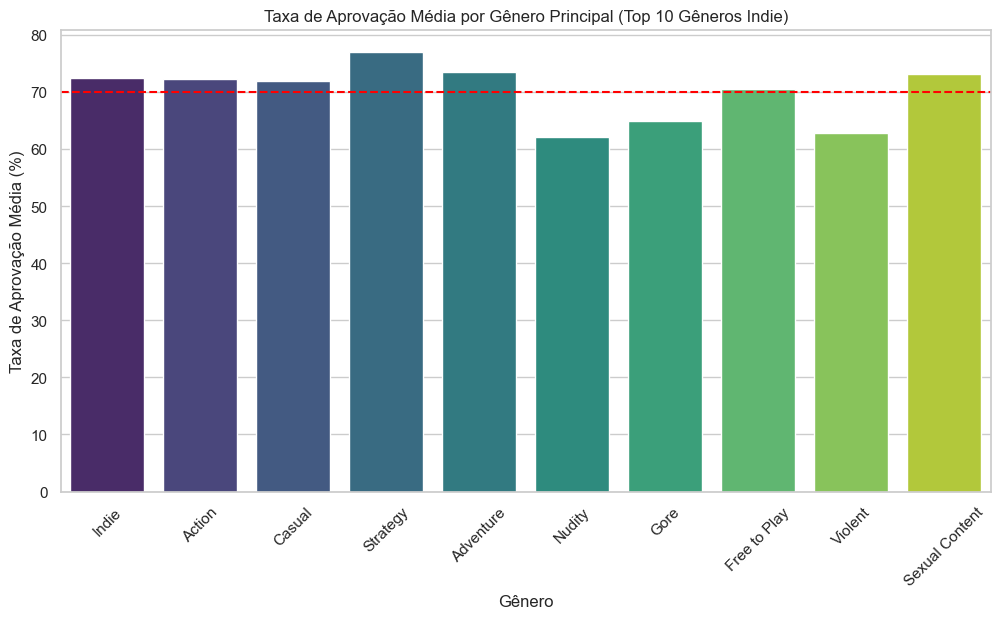

In [6]:
# Recriando o dataframe com a garantia de que a coluna 'genres' está lá
df_graficos = df_indie[df_indie['price'] <= 60].copy()
df_graficos['total_ratings'] = df_graficos['positive_ratings'] + df_graficos['negative_ratings']
df_graficos['taxa_aprovacao'] = (df_graficos['positive_ratings'] / df_graficos['total_ratings']) * 100
df_graficos = df_graficos.dropna(subset=['taxa_aprovacao'])

# Criando a coluna do gênero principal
df_graficos['main_genre'] = df_graficos['genres'].apply(lambda x: str(x).split(';')[0])

#  Descobrindo os top 10 gêneros
top_10_generos = df_graficos['main_genre'].value_counts().head(10).index
df_top_generos = df_graficos[df_graficos['main_genre'].isin(top_10_generos)]

# Gerando o Gráfico 3
plt.figure(figsize=(12, 6))
#  Gerando o Gráfico 3 (Sem o aviso do FutureWarning)
plt.figure(figsize=(12, 6))

sns.barplot(data=df_top_generos, x='main_genre', y='taxa_aprovacao', hue='main_genre', palette='viridis', errorbar=None, legend=False)

plt.title('Taxa de Aprovação Média por Gênero Principal (Top 10 Gêneros Indie)')
plt.xlabel('Gênero')
plt.ylabel('Taxa de Aprovação Média (%)')
plt.xticks(rotation=45)
plt.axhline(y=70, color='red', linestyle='--', label='Linha de 70% (Aprovação)')
plt.show()